In [ ]:
# import StateGraph to store state of input, output and result
from langgraph.graph import StateGraph , START, END
from typing import TypedDict

In [ ]:
# call to define all input and output data type
class BMIState(TypedDict):

    weight_kg: float  # weight in kg
    height_m: float   # height in meter
    bmi: float          # BMI value
    category: str      # based on BMI value (underwight or overweight or fit)


In [ ]:
#function to calculate bmi
def calculate_bmi(state: BMIState) -> BMIState:
    
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight /(height**2)

    state['bmi'] = round(bmi,2)

    return state

In [ ]:
#function to check in which category bmi falls
def category(state: BMIState) -> BMIState :

    bmi = state['bmi']

    if bmi < 18.5 :
        state['category'] = "UnderWeight"

    elif 18.5 <= bmi < 25:
        state['category'] = "Normal"

    elif 25 <= bmi < 30:
        state['category'] = "Overweight"
    
    else:
         state['category'] = "obese"
   
    
    return state


In [116]:
#define graph
graph = StateGraph(BMIState)

#add node

graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('category',  category)


#add edge 

graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'category')
graph.add_edge('category', END)


# compile the graph
workflow = graph.compile()



In [117]:
#execute the workflow
intial_state = {'weight_kg': 80, 'height_m': 1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


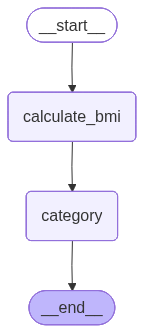

In [118]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())